In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import textwrap
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Загружаем датасет

In [2]:
from datasets import load_dataset

ds = load_dataset("gvlassis/california_housing")

In [3]:
df = pd.DataFrame(ds["train"])
df_val = pd.DataFrame(ds["validation"])

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16640.000000,16640.000000,16640.000000,16640.000000,16640.000000,16640.000000,16640.000000,16640.000000,16640.000000
mean,3.797641,29.221995,5.396218,1.101687,1436.939123,3.007617,35.267714,-119.146628,2.018484
std,1.867145,12.797845,2.648682,0.511507,1159.762831,5.114548,2.086404,1.923576,1.132658
min,0.499900,1.000000,0.846154,0.375000,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.526300,19.000000,4.379310,1.007401,792.000000,2.425249,33.870000,-121.240000,1.183000
50%,3.474500,30.000000,5.166053,1.050725,1168.000000,2.831033,34.100000,-118.300000,1.736000
75%,4.635475,38.000000,6.000000,1.101127,1727.000000,3.309981,37.710000,-117.890000,2.530250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,599.714286,41.950000,-114.310000,5.000010


In [6]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

# Очистка от выбросов

In [7]:
# Определяем функции очистки от выбросов

def clear_outliers_quantile(df_orig):
    df = df_orig.copy()
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        bottom = Q1 - 1.5 * IQR
        top = Q3 + 1.5 * IQR
        df = df[(df[col] >= bottom) & (df[col] <= top)]
    return df

def clear_outliers_z(df_orig, threshold=3):
    df = df_orig.copy()
    for col in df.columns:
        mean = df[col].mean()
        std = df[col].std()
        df = df[abs((df[col] - mean) / std) < threshold]
    return df

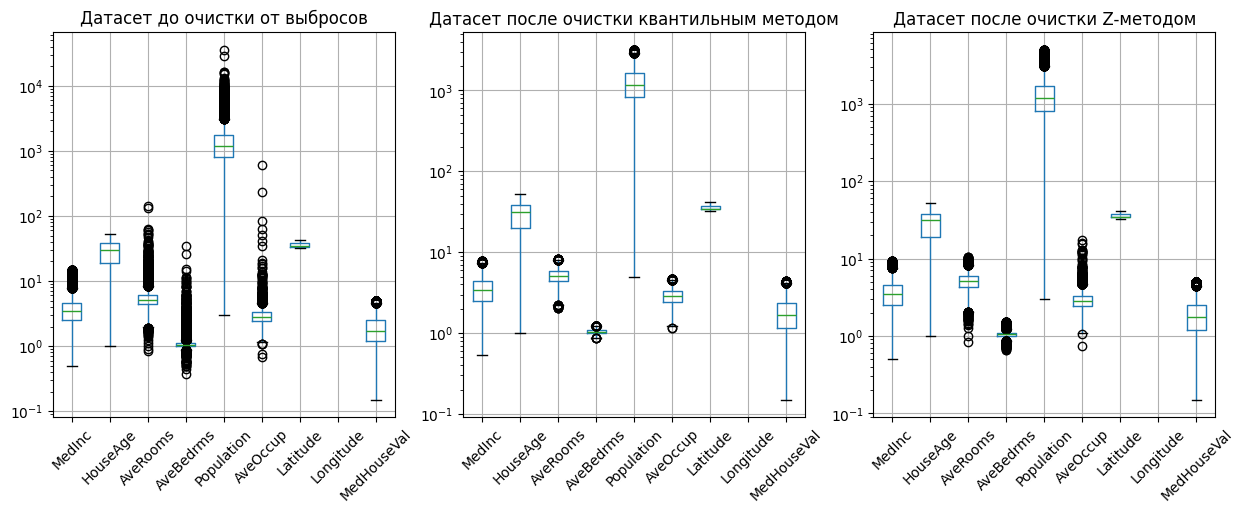

In [8]:
# Строим boxplot'ы

fig = plt.figure(figsize=(15, 5))
columns = 3
rows = 1

df_quantile = clear_outliers_quantile(df)
df_z = clear_outliers_z(df)

fig.add_subplot(rows, columns, 1)
df.boxplot()
plt.title("Датасет до очистки от выбросов")
plt.yscale("log")
plt.xticks(rotation=45)

fig.add_subplot(rows, columns, 2)
df_quantile.boxplot()
plt.title("Датасет после очистки квантильным методом")
plt.yscale("log")
plt.xticks(rotation=45)

fig.add_subplot(rows, columns, 3)
df_z.boxplot()
plt.title("Датасет после очистки Z-методом")
plt.yscale("log")
plt.xticks(rotation=45)

plt.show()

# Отбор признаков (жадный алгоритм)

In [9]:
# Предобрабатываем датасет
df = clear_outliers_quantile(df)
df_val = clear_outliers_quantile(df)

scaler = MinMaxScaler()
df[:] = scaler.fit_transform(df)
df_val[:] = scaler.transform(df_val)

<Axes: >

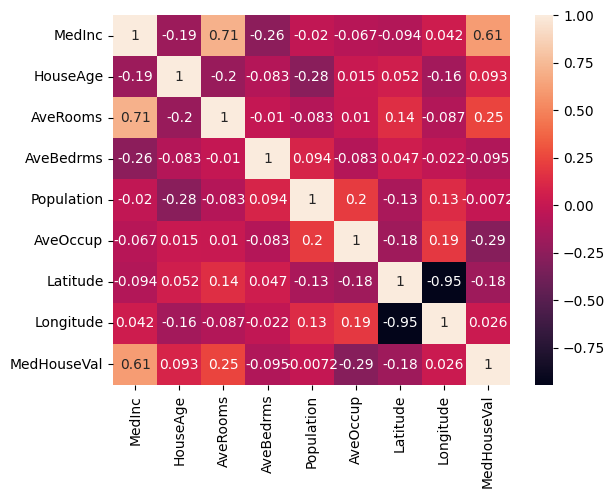

In [10]:
sns.heatmap(df.corr(), annot=True)

In [11]:
# Будем предсказывать MedInc (Medium Income)
y_train = df["MedInc"]
x_train = df.drop(columns=["MedInc"])

y_val = df_val["MedInc"]
x_val = df_val.drop(columns=["MedInc"])

In [12]:
errors = []
chosen_cols = []

for i in range(len(x_train.columns)):

    print(f"----------Итерация {i+1}----------")
    print("Добавляемая колонка:\t MSE:")

    min_error = np.inf
    col_with_min_error = ""

    for added_col in x_train.columns.drop(chosen_cols):
        curr_cols = chosen_cols + [added_col]
        curr_x_train = x_train[curr_cols]
        curr_x_val = x_val[curr_cols]
        
        regressor = LinearRegression()
        regressor.fit(curr_x_train, y_train)

        y_pred = regressor.predict(curr_x_val)
        curr_error = mean_squared_error(y_val, y_pred)

        print(added_col, "\t\t", round(curr_error, 4))

        if curr_error < min_error:
            min_error = curr_error
            col_with_min_error = added_col

    chosen_cols += [col_with_min_error]
    errors.append(min_error)

    print()
    # Textwrap для того, чтобы переносилось на следующую строку
    print(textwrap.fill(f"Выбранные колонки: {chosen_cols}", width=50))
    print(f"Нынешняя ошибка: {min_error}\n")

----------Итерация 1----------
Добавляемая колонка:	 MSE:
HouseAge 		 0.0329
AveRooms 		 0.0176
AveBedrms 		 0.0316
Population 		 0.0339
AveOccup 		 0.0338
Latitude 		 0.0336
Longitude 		 0.0338
MedHouseVal 		 0.0216

Выбранные колонки: ['AveRooms']
Нынешняя ошибка: 0.017632451160341806

----------Итерация 2----------
Добавляемая колонка:	 MSE:
HouseAge 		 0.0176
AveBedrms 		 0.0154
Population 		 0.0176
AveOccup 		 0.0175
Latitude 		 0.0162
Longitude 		 0.0172
MedHouseVal 		 0.0105

Выбранные колонки: ['AveRooms', 'MedHouseVal']
Нынешняя ошибка: 0.01048307561361553

----------Итерация 3----------
Добавляемая колонка:	 MSE:
HouseAge 		 0.0101
AveBedrms 		 0.0089
Population 		 0.0105
AveOccup 		 0.0103
Latitude 		 0.0102
Longitude 		 0.0102

Выбранные колонки: ['AveRooms', 'MedHouseVal',
'AveBedrms']
Нынешняя ошибка: 0.008940213944892033

----------Итерация 4----------
Добавляемая колонка:	 MSE:
HouseAge 		 0.0084
Population 		 0.0088
AveOccup 		 0.0089
Latitude 		 0.0086
Longitude 		 0.

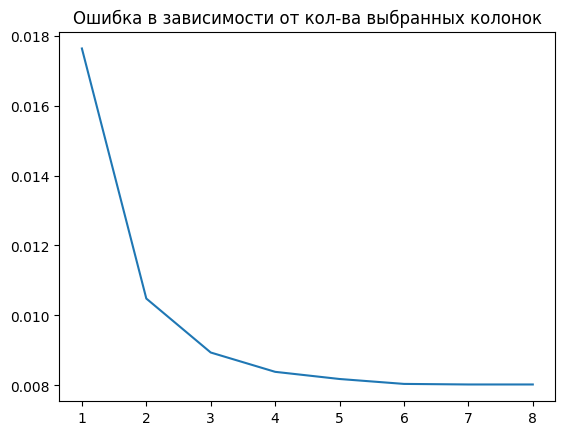

In [13]:
plt.title("Ошибка в зависимости от кол-ва выбранных колонок")
plt.plot(list(range(1, 9)), errors)
plt.show()

Вывод: для хорошей работы модели достаточно первых 3-4 колонок. <br>
(['AveRooms', 'MedHouseVal', 'AveBedrms', 'HouseAge'])